In [1]:
'''
Load dicom from own dicom storage, then apply the API to the dicom
'''

'\nLoad dicom from own dicom storage, then apply the API to the dicom\n'

In [14]:
import http
import pydicom
import io
import subprocess
from typing import Iterable, Optional
from google.oauth2 import credentials
from google.auth import credentials as gcredentials
from google.auth.transport import requests
import dicomweb_client.uri as dicomweb_uri
import dicomweb_client.ext.gcp.uri as gcp_uri
from requests_toolbelt.multipart import decoder
import matplotlib.pyplot as plt

In [3]:
"""Google Cloud Healthcare (CHC) DICOMweb utilities."""

# Well-known constants from https://www.dicomstandard.org/.
_STUDY_INSTANCE_UID_TAG = '0020000D'
_SERIES_INSTANCE_UID_TAG = '0020000E'
_SOP_INSTANCE_UID_TAG = '00080018'

_SERIES_INSTANCE_UID_SEARCH_SUFFIX = 'series'
_STUDY_INSTANCE_UID_SEARCH_SUFFIX = 'studies'
_SOP_INSTANCE_UID_SEARCH_SUFFIX = 'instances'

_VALUE_KEY = 'Value'

# Scope requirements from:
# https://cloud.google.com/healthcare-api/docs/reference/rest/v1/projects.locations.datasets.dicomStores/searchForInstances#authorization-scopes
_AUTHORIZATION_SCOPES = ['https://www.googleapis.com/auth/cloud-healthcare']

# Search result limits for the CHC DICOMweb API:
# https://cloud.google.com/healthcare-api/docs/dicom#search_parameters
_MAX_LIMIT_STUDY = 5000
_MAX_LIMIT_SERIES = 5000
_MAX_LIMIT_SOP = 50000
_MAX_OFFSET = 1000000

_MAX_REFRESH_ATTEMPTS = 10
_REQUEST_TIMEOUT_SECONDS = 600


def create_authorized_session(
    credentials: gcredentials.Credentials,
) -> requests.AuthorizedSession:
  """Creates a Session authorized for Cloud Healthcare API interactions.

  Args:
    credentials: Google Auth credentials. For further details, see
      https://googleapis.dev/python/google-auth/latest/index.html.

  Returns:
    Credentials object with the requisite API scope.
  """
  authorization_scopes = _AUTHORIZATION_SCOPES
  scoped_credentials = gcredentials.with_scopes_if_required(
      credentials, authorization_scopes
  )
  return requests.AuthorizedSession(
      scoped_credentials, max_refresh_attempts=_MAX_REFRESH_ATTEMPTS
  )


def download_multipart_dicom_series(
    project_id: str,
    location: str,
    dataset_id: str,
    dicom_store_id: str,
    session: requests.AuthorizedSession,
    study_instance_uid: str,
    series_instance_uid: str,
) -> Iterable[bytes]:
  """Downloads all SOP Instances (DICOMs) within a Series Instance UID.

  The request accepts a multipart MIME response from the CHC DICOMweb API to
  reduce the:
  - Latency associated with making one API call per Instance.
  - API quota usage while downloading all Instances within a Series.

  Args:
    project_id: The GCP Project containing the DICOM Store to query.
    location: The regional location associated with the DICOM Store (c.f.
      https://cloud.google.com/healthcare-api/docs/regions).
    dataset_id: The Dataset containing the DICOM Store (c.f.
      https://cloud.google.com/healthcare-api/docs/projects-datasets-data-stores)
    dicom_store_id: The DICOM Store to query.
    session: An Google Auth session authorized to use the CHC DICOMweb API.
    study_instance_uid: The Study Instance UID containing the Series Instance
      UID to download.
    series_instance_uid: The Series Instance UID containing the SOP Instances
      (DICOMs) to download.

  Yields:
    DICOM bytes associated with each Instance contained within the input Series
    Instance UID.
  """
  dicomweb_path = str(
      dicomweb_uri.URI(
          str(
              gcp_uri.GoogleCloudHealthcareURL(
                  project_id, location, dataset_id, dicom_store_id
              )
          ),
          study_instance_uid,
          series_instance_uid,
      )
  )

  headers = {
      'Accept': (
          'multipart/related; transfer-syntax=1.2.840.10008.1.2.1;'
          ' type="application/dicom"'
      )
  }
  response = session.get(
      dicomweb_path, headers=headers, timeout=_REQUEST_TIMEOUT_SECONDS
  )
  response.raise_for_status()

  for part in decoder.MultipartDecoder.from_response(response).parts:
    yield part.content


def search_study_instance_uids(
    project_id: str,
    location: str,
    dataset_id: str,
    dicom_store_id: str,
    session: requests.AuthorizedSession,
    limit: int = 100,
) -> Iterable[str]:
  """Recovers all Study Instance UIDs from a CHC DICOM Store.

  Args:
    project_id: The GCP Project containing the DICOM Store to query.
    location: The regional location associated with the DICOM Store (c.f.
      https://cloud.google.com/healthcare-api/docs/regions).
    dataset_id: The Dataset containing the DICOM Store (c.f.
      https://cloud.google.com/healthcare-api/docs/projects-datasets-data-stores)
    dicom_store_id: The DICOM Store to query.
    session: An Google Auth session authorized to use the CHC DICOMweb API.
    limit: The number of Study Instance UIDs in the DICOM Store could be large.
      The UIDs are recovered in a paginated fashion, where each page of results
      (one page per query) includes at most `limit` values. The higher this
      value, the fewer the total number of requests, but each response would be
      larger. Depending on your network connection, set this value in the range
      1 through 5000 (both inclusive). This parameter impacts the speed and
      network bandwidth utilization, but not the values returned by the method.

  Yields:
    Study Instance UIDs from the DICOM Store.

  Raises:
    ValueError: If `limit` exceeds the max value of 5000 allowed by the CHC
      DICOMweb API (c.f.
      https://cloud.google.com/healthcare-api/docs/projects-datasets-data-stores)
  """
  if limit > _MAX_LIMIT_STUDY:
    raise ValueError(
        f'Request limit {limit} exceeds the CHC Search query request limit of'
        f' {_MAX_LIMIT_STUDY} for Study Instances.'
    )
  yield from _search_dicom_data(
      project_id,
      location,
      dataset_id,
      dicom_store_id,
      _STUDY_INSTANCE_UID_SEARCH_SUFFIX,
      _STUDY_INSTANCE_UID_TAG,
      session,
      limit,
  )


def search_series_instance_uids(
    project_id: str,
    location: str,
    dataset_id: str,
    dicom_store_id: str,
    session: requests.AuthorizedSession,
    study_instance_uid: Optional[str] = None,
    limit: int = 100,
) -> Iterable[str]:
  """Recovers all Series Instance UIDs from a CHC DICOM Store.

  The scope may be restricted to all Series within a fixed Study Instance
  UIDs (see `study_instance_uid` below).

  Args:
    project_id: The GCP Project containing the DICOM Store to query.
    location: The regional location associated with the DICOM Store (c.f.
      https://cloud.google.com/healthcare-api/docs/regions).
    dataset_id: The Dataset containing the DICOM Store (c.f.
      https://cloud.google.com/healthcare-api/docs/projects-datasets-data-stores)
    dicom_store_id: The DICOM Store to query.
    session: An Google Auth session authorized to use the CHC DICOMweb API.
    study_instance_uid: If provided, restricts the returned Series Instance UIDs
      to within this Study Instance UID.
    limit: The number of Study Instance UIDs in the DICOM Store could be large.
      The UIDs are recovered in a paginated fashion, where each page (query)
      includes at most `limit` values. The higher this value, the fewer the
      total number of requests, but each response would be larger. Depending on
      your network connection, set this value in the range 1 through 5000 (both
      inclusive).

  Yields:
    Series Instance UIDs from the DICOM Store (optionally within the scope of
    the input `study_instance_uid`, if provided).

  Raises:
    ValueError: If `limit` exceeds the max value of 5000 allowed by the CHC
      DICOMweb API (c.f.
      https://cloud.google.com/healthcare-api/docs/projects-datasets-data-stores)
  """
  if limit > _MAX_LIMIT_SERIES:
    raise ValueError(
        f'Request limit {limit} exceeds the CHC Search query request limit of'
        f' {_MAX_LIMIT_SERIES} for Series Instances.'
    )
  search_suffix = (
      _SERIES_INSTANCE_UID_SEARCH_SUFFIX
      if study_instance_uid is None
      else f'studies/{study_instance_uid}/series'
  )
  yield from _search_dicom_data(
      project_id,
      location,
      dataset_id,
      dicom_store_id,
      search_suffix,
      _SERIES_INSTANCE_UID_TAG,
      session,
      limit,
  )


def _search_dicom_data(
    project_id: str,
    location: str,
    dataset_id: str,
    dicom_store_id: str,
    query_suffix: str,
    dicom_tag: str,
    session: requests.AuthorizedSession,
    limit: int,
) -> Iterable[str]:
  """Generates DICOM UIDs from a CHC DICOM Store."""
  assert limit > 0

  uri = gcp_uri.GoogleCloudHealthcareURL(
      project_id, location, dataset_id, dicom_store_id
  )
  base_dicomweb_query_path = f'{uri}/{query_suffix}?includefield={dicom_tag}'
  headers = {'Content-Type': 'application/dicom+json; charset=utf-8'}

  # The CHC offset limit puts an upper bound on the Instance count, which is
  # also used to limit the number of iterations.
  for offset in range(0, _MAX_OFFSET, limit):
    dicomweb_query_path = (
        f'{base_dicomweb_query_path}&offset={offset}&limit={limit}'
    )

    response = session.get(
        dicomweb_query_path, headers=headers, timeout=_REQUEST_TIMEOUT_SECONDS
    )
    response.raise_for_status()
    # CHC DICOMweb API does not set a Warning response header on the last
    # available page:
    # https://cloud.google.com/healthcare-api/docs/dicom#search_parameters
    if response.status_code == http.HTTPStatus.NO_CONTENT:
      return

    for instance in response.json():
      assert dicom_tag in instance
      assert _VALUE_KEY in instance[dicom_tag]

      for value in instance[dicom_tag][_VALUE_KEY]:
        yield value

In [4]:
TOKEN = subprocess.run(['gcloud', 'auth', 'application-default', 'print-access-token'], stdout=subprocess.PIPE).stdout.decode('utf-8').strip('\n')
TOKEN

'ya29.a0ARW5m771YpppI8Td-We0tjhWrK-THpfzsW-Z4ipU1pfiJrSaexb5gGbGDP-jiNPKkaKAR25aLxMH0RhLmJQI9wK2QevjoRSOspYtVnPdNb5dEzt101fLRZVMzFHYyi2dQJqNFk93R17mc1QW4K8Ehpm_9J0Peo5qAjlH0Zyu_waCgYKAQYSARISFQHGX2MiWkG2LG1nFcd23mg4la5vSQ0177'

In [5]:
creds = credentials.Credentials(TOKEN)
session = create_authorized_session(creds)

In [6]:
# @title Set DICOM store parameters
project_id='fleet-space-445215-f7' # @param {type:"string"}
location='northamerica-northeast2'  # @param {type:"string"}
dataset_id='brain_ct_stroke'  # @param {type:"string"}
dicom_store_id='ct_foundation_stroke_dataset' # @param {type:"string"}

In [8]:
# @title List the study and series instance UIDs and download a single volume.

TOTAL_VOLUMES = 1  # Total number to list out.
VOLUME_TO_SHOW = 0 # Which ones to render below

study_uids = list(search_study_instance_uids(
    project_id=project_id,
    location=location,
    dataset_id=dataset_id,
    dicom_store_id=dicom_store_id,
    session=session))


corresponding_series_uids = []
for study_number, a_study_uid in enumerate(study_uids):
  a_series = list(search_series_instance_uids(project_id=project_id,
    location=location,
    dataset_id=dataset_id,
    dicom_store_id=dicom_store_id,
    session=session, study_instance_uid=a_study_uid))[0]
  corresponding_series_uids.append(a_series)
  if study_number == TOTAL_VOLUMES:
    break


volume_as_bytes = list(download_multipart_dicom_series(
      project_id=project_id,
      location=location,
      dataset_id=dataset_id,
      dicom_store_id=dicom_store_id,
      session=session,
      study_instance_uid=study_uids[VOLUME_TO_SHOW],
      series_instance_uid=corresponding_series_uids[VOLUME_TO_SHOW],
  ))

print(f'Total Slices in downloaded volume: {len(volume_as_bytes)}')

Total Slices in downloaded volume: 17


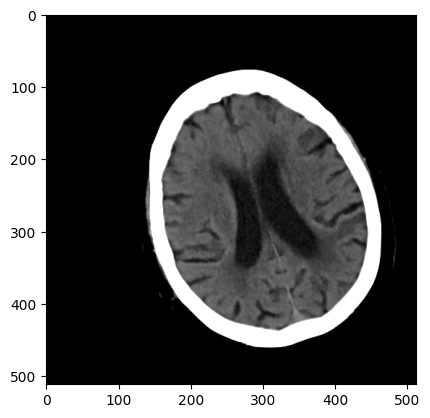

In [18]:
#@title Render a single slice
SLICE_TO_RENDER = 9
example_dicom = pydicom.dcmread(io.BytesIO(volume_as_bytes[SLICE_TO_RENDER]))

img = example_dicom.pixel_array.copy()

plt.imshow(img, 'gray', vmin=1024, vmax=1124)

In [20]:
#@title Python methods to call CT Foundation's API.

from concurrent.futures import ThreadPoolExecutor
import dataclasses
import functools
import json
from typing import Any, Tuple
import google.auth
import google.auth.transport.requests
import numpy as np


@dataclasses.dataclass(eq=False, frozen=True)
class Response:
  """Response from a Vertex Endpoint."""

  status_code: int
  response_json: dict[str, Any] | None  # json_types.JSONObject


class Endpoint:
  """Calling utility for a Vertex Endpoint using default credentials."""

  def __init__(self):
    self._endpoint_url = (
        'https://us-central1-aiplatform.googleapis.com/v1/projects/'
        'hai-cd3-foundations/locations/us-central1/endpoints/300')

  def predict(
      self,
      instances=list[Any],
      parameters: dict[str, Any] | None = None,
      credentials: google.auth.credentials.Credentials | None = None,
  ) -> Response:
    """Calls the Vertex Endpoint with the given instances and parameters."""
    if credentials is None:
      credentials = google.auth.default()[0]
    session = google.auth.transport.requests.AuthorizedSession(
        credentials=credentials
    )
    response = session.post(
        self._endpoint_url + ':predict',
        json=(
            {'instances': instances}
            | ({'parameters': parameters} if parameters is not None else {})
        ),
        headers={
            'Content-Type': 'application/json',
        },
        timeout=400
    )
    try:
      response_json = response.json()
    except json.JSONDecodeError:
      # Not expected, handling in case server incorrectly returns non-JSON.
      response_json = None
    return Response(
        status_code=response.status_code,
        response_json=response_json,
    )


def call_single_batch(
    caller: Endpoint,
    credentials,
    urls: list[str],
    access_token: str
) -> list[Tuple[np.ndarray | str, str]]:
  """Handles calls for a single batch and returns embeddings."""
  return_data = []
  if not credentials.valid:
    credentials.refresh(google.auth.transport.requests.Request())
  instances = [{
      "dicom_path": a_url, "bearer_token": f"{access_token}"} for a_url in urls]
  returns = caller.predict(instances=instances)
  if returns.status_code != 200:
    for a_url in urls:
      return_data.append((f'FAIL STATUS {returns.status_code}', a_url))
    return return_data
  else:
    for i in range(len(returns.response_json['predictions'])):
      if returns.response_json['predictions'][i]['error_response']:
        return_data.append((
            returns.response_json['predictions'][i]['error_response'], urls[i]))
      else:
        embeddings = returns.response_json['predictions'][i][
            'embedding_result'
        ]['embedding']
        return_data.append((embeddings, urls[i]))
    return return_data


def get_ct_embbeddings(
    caller: Endpoint,
    credentials,
    urls: list[str],
    access_token: str,
    batch_size: int,
    parallel_size: int,
) -> list[Tuple[np.ndarray | str, str]]:
  """Handles calls and returns for parallel requests.

  Args:
    caller: CT foundation API caller.
    credentials: The credentials for the API.
    urls: List of urls to the DICOM store for series to run.
      This must be of length batch_size * parallel_size.
    access_token: Access token for the DICOM store.
    batch_size: The number of volumes to pass in a batch (max 5).
    parallel_size: The number of parallel calls.

  Returns:
    Tuple list of embeddings | errors and the corresponding urls from which
      the embeddings were computed.
  """
  assert batch_size < 6, 'Batch size must be 5 or less.'
  assert (
      len(urls) == batch_size * parallel_size
  ), 'Error in batch, parallel sizes versus requests'

  # Setup up parallel batches
  p_urls = []
  for i in range(parallel_size):
    p_urls.append(urls[i * batch_size : (i + 1) * batch_size])

  # Check for correct sizing
  assert len(p_urls) == parallel_size, 'Error in batch, parallel dimensions'

  call_batch = functools.partial(call_single_batch, caller, credentials)

  # Launch parallel calls
  with ThreadPoolExecutor(max_workers=parallel_size) as executor:
    futures = [
        executor.submit(call_batch, b_urls, access_token) for b_urls in p_urls
    ]
    results = [f.result() for f in futures]
  # Unpack results into a single list
  return_results = []
  for b_result in results:
    for a_result in b_result:
      return_results.append(a_result)
  return return_results


In [21]:
#@title Create a URL, token, and call the API for the DICOM volume

def create_lidc_series_url(study_instance_uid, series_instance_uid):
  """Create a URL to the specific LIDC DICOM volume."""
  return (f'https://healthcare.googleapis.com/v1/projects/{project_id}/'
          f'locations/{location}/datasets/{dataset_id}/dicomStores/{dicom_store_id}/dicomWeb/'
          f'studies/{study_instance_uid}/series/{series_instance_uid}')

# Credentials to access the API
credentials = google.auth.default()[0]

# Token to access the DICOMs in the DICOM store
TOKEN = subprocess.run(['gcloud', 'auth', 'application-default', 'print-access-token'], stdout=subprocess.PIPE).stdout.decode('utf-8').strip('\n')

# The url pointing to the specific DICOM series that can be accessed via
# the above token.
my_url = create_lidc_series_url(study_uids[VOLUME_TO_SHOW],
                                corresponding_series_uids[VOLUME_TO_SHOW])

# Call the API with a single call and a batch size of 1.
my_embeddings = get_ct_embbeddings(
    caller=Endpoint(), credentials=credentials, urls=[my_url],
    access_token=TOKEN, batch_size=1, parallel_size=1)
# Total passed urls are 1
print(f'Embeddings or error message for the CT in the DICOM store at: {my_embeddings[0][1]}')
print(my_embeddings[0][0])



/usr/local/lib/python3.11/dist-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/usr/local/lib/python3.11/dist-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Embeddings or error message for the CT in the DICOM store at: https://healthcare.googleapis.com/v1/projects/fleet-space-445215-f7/locations/northamerica-northeast2/datasets/brain_ct_stroke/dicomStores/ct_foundation_stroke_dataset/dicomWeb/studies/1.2.826.0.1.3680043.6.5361.8597.20170816184324.772.46/series/1.3.12.2.1107.5.1.4.76937.30000017081402521162000367492
[1.078068017959595, -0.5945754647254944, -0.6096419095993042, -1.198771238327026, -1.173517823219299, -0.04547826945781708, -1.289033055305481, -0.3085144758224487, -1.485343933105469, 0.5608125329017639, -1.095183372497559, 1.060403227806091, -0.6662912964820862, -1.103694915771484, -1.139890670776367, -0.4290373027324677, 2.06239652633667, 1.41011917591095, 0.3478374183177948, -1.477543592453003, -0.1203067302703857, -0.5047408938407898, -0.8305891752243042, -0.9028199911117554, 0.3310419619083405, 0.0710567981004715, -1.86774754524231, 1.331711292266846, -1.59861147403717, -0.2663238048553467, 1.046558260917664, 0.52302604913